# Trabalho Computacional 8
## PPGEE 2166 Processos Estocásticos (2026.1)
- Discente: Thiago Tomás de Paula (242104677)
- Data: 15/07/2026

### Item 8.1 

Idêntico ao Trabalho 7, só que agora você deve usar o arquivo `data_Lung_Cancer.csv`.

---

### Análise exploratória dos dados

Esta etapa do estudo gera e analisa os seguintes itens:

0. retrato de dados faltantes ou indefinidos;
1. listagem das classes: nomes, descrições e unidades;
2. listagem das features: nomes, descrições e unidades;
3. gráficos de dispersões e histogramas das features;
4. matriz de correlação de Pearson entre as features desconsiderando classes;
5. matriz de correlação de Pearson entre as features por cada classe. 

**Carregamento dos dados.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo para os gráficos
COLORMAP = "Set1"
sns.set_style('whitegrid')
sns.set_palette(COLORMAP)
plt.set_cmap(COLORMAP)

# Guarda os dados do arquivo CSV em um DataFrame do Pandas
caminho_dos_dados = "data_Lung_Cancer.csv"
dados = pd.read_csv(caminho_dos_dados)
COLUNA_CLASSE = "class"

<Figure size 640x480 with 0 Axes>

**Checagem dos dados.** 

A rigor, o dataset é completamente anonimizado, tornando incerta qualquer interpretação.
O dataset é uma matriz com 32 linhas e 57 colunas, sendo uma delas a coluna de classe.

A figura abaixo mostra que há dados faltantes/indefinidos no dataset.
Linhas afetadas (5 ao todo) são removidas antes de dar sequência à análise exploratória.

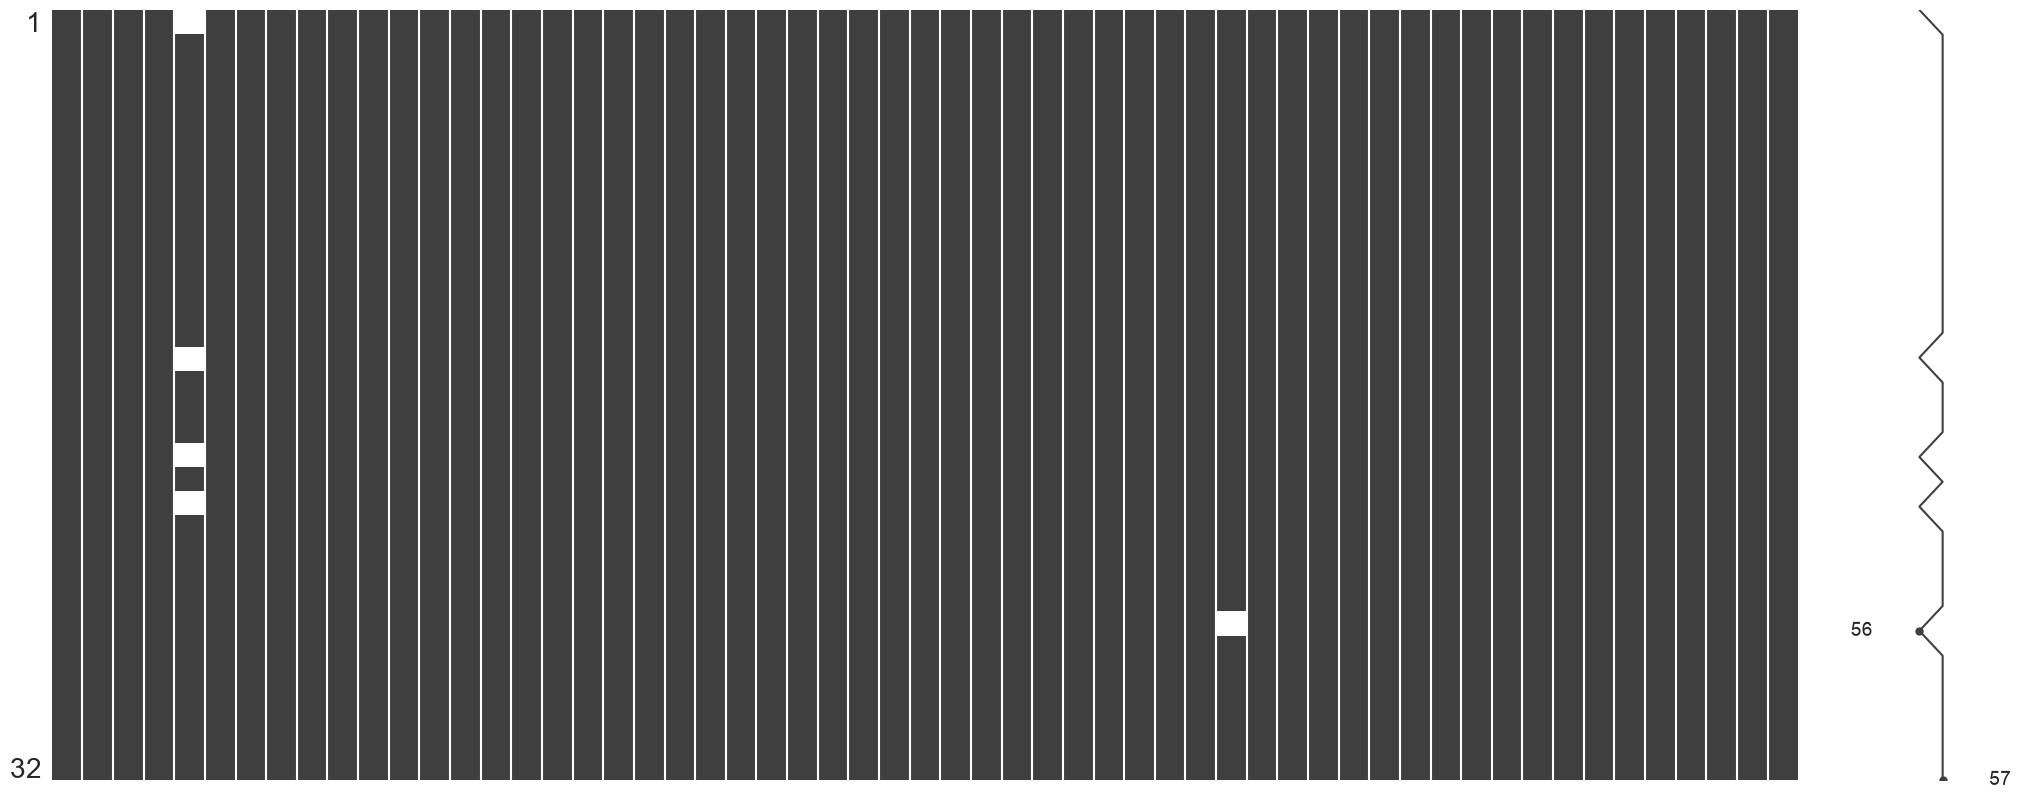

In [2]:
# 0. retrato de dados faltantes ou indefinidos
import missingno as msno
msno.matrix(dados)

# Remove linhas com valores faltantes ou indefinidos
dados = dados.dropna()

**Classes.**

A coluna `class` possui dois valores, 1, 2 ou 3. 
O significado de cada valor é desconhecido.

Das 27 amostras, 
8 (29.6%) pertencem à classe 1,
10 (37.0%) pertencem à classe 2, e
9 (33.3%) pertencem à classe 3.

Apesar do bom balanceamento entre as classes, a quantidade de amostras é pequena, o que pode comprometer a performance de classificadores.

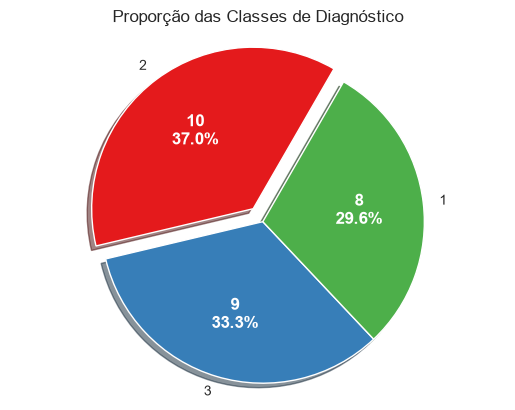

In [3]:
# 1. listagem das classes: nomes, descrições e unidades. 
## Proporção das classes em % com 2 casas decimais
def plotar_proporcao_classes(dados, coluna_classe=COLUNA_CLASSE, colormap=COLORMAP, titulo="Proporção das Classes de Diagnóstico", ax=None):
    _valores_proporcionais = dados[coluna_classe].value_counts(normalize=True).mul(100).round(2)
    _valores_absolutos = dados[coluna_classe].value_counts()
    _df_classes = pd.DataFrame({
        "Classe": _valores_absolutos.index, 
        "Quantidade": _valores_absolutos.values, 
        "Proporção (%)": _valores_proporcionais.values
    })

    # Gráfico de pizza para visualização da proporção e quantidade das classes
    if ax is None:
        _, ax = plt.subplots()
    pie = ax.pie(
        _df_classes["Quantidade"], 
        colors=sns.color_palette(colormap), 
        labels=_df_classes["Classe"], 
        shadow=True, 
        startangle=60, 
        explode=(0.1, 0, 0)
    )
    _ = ax.pie_label(pie, '{absval:d}\n{frac:.1%}', textprops={'fontsize': 'large', 'color': 'white', 'weight': 'bold'})
    _ = ax.set_title(titulo)
    _ = plt.axis('equal')

plotar_proporcao_classes(dados)

**Features.**

O dataset possui 56 features ao todo. 
O sentido físico/estatístico dessas variáveis não está disponível. 

**Histogramas.** 

Os histogramas das features, apresentados abaixo, mostram que não há separação clara entre as classes -
pelo menos não no espaço de features original.
Isso levanta preocupações com a performance de classificadores baseados em discriminantes,
e junto com o desbalanceamento do dataset torna a boa performance improvável.

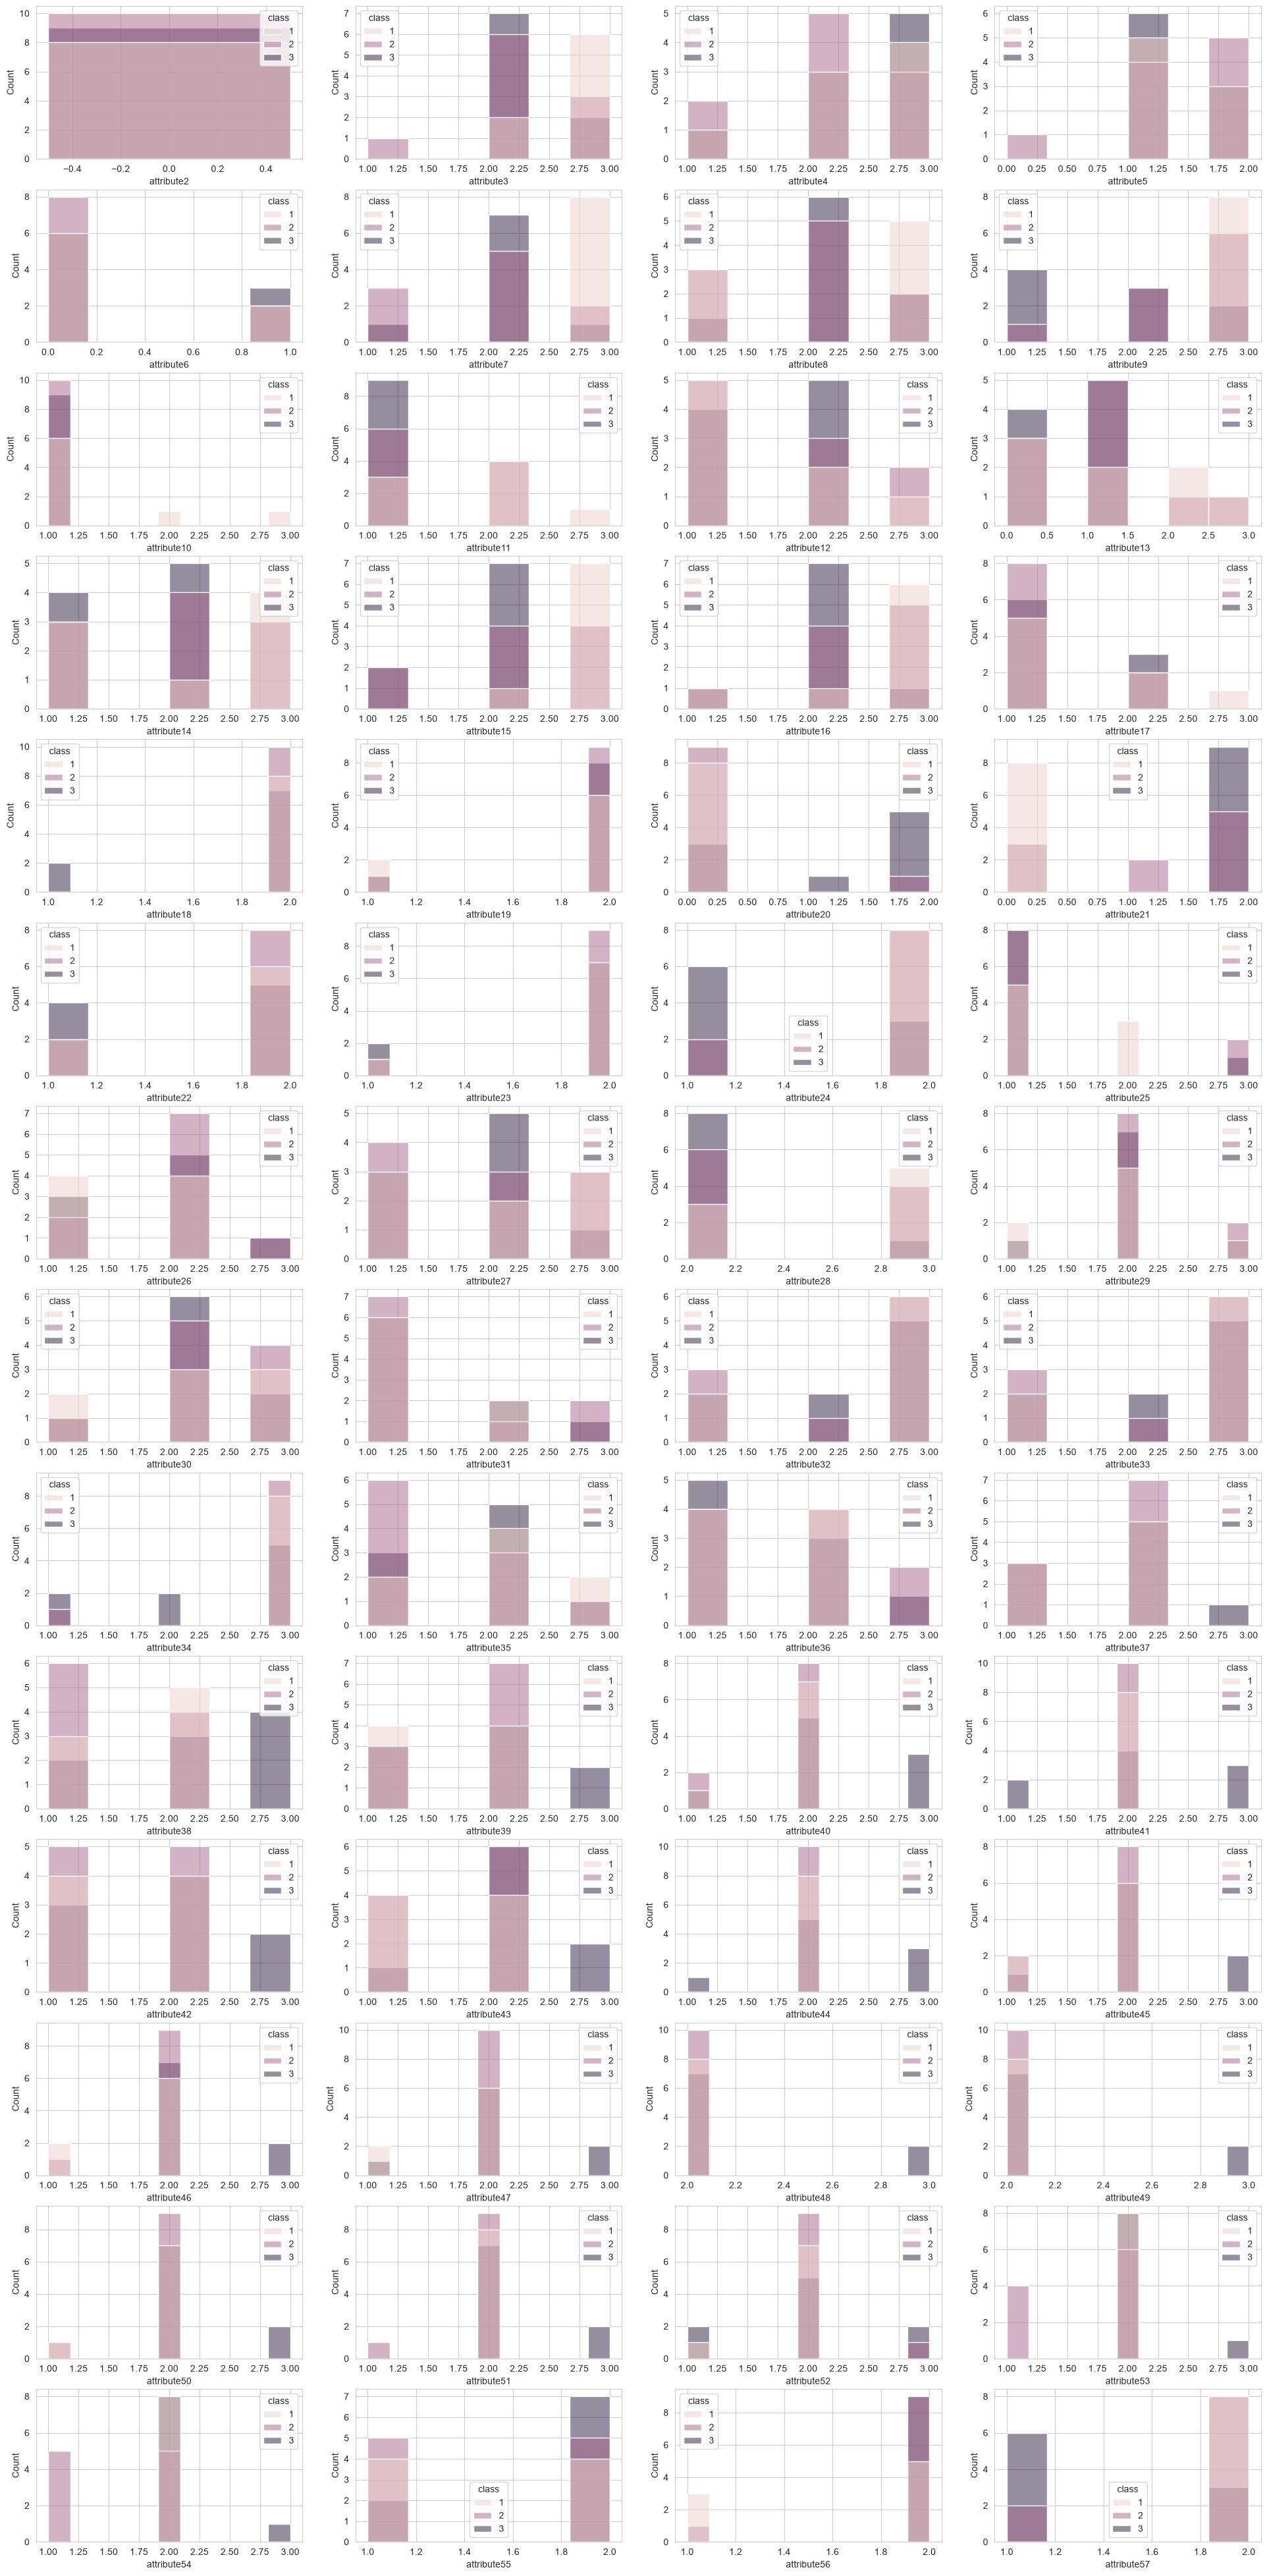

In [4]:
# 3. gráficos de dispersões e histogramas das features
fig, axes = plt.subplots(nrows=14, ncols=4, figsize=(24, 50))
i, j = 0, 0
for feature in dados.columns:
    if feature != COLUNA_CLASSE:
        sns.histplot(data=dados, x=feature, hue=COLUNA_CLASSE, ax=axes[i, j])
        i = i + 1 if j == 3 else i
        j = 0 if j == 3 else j + 1

### Comparação de performance em apenas um caso

Terminada a análise exploratória, as amostras do dataset são preparadas para classificação.

A preparação consiste em dois passos: o embaralhamento de amostras, e a partição das amostras treino (80%) e teste (20%).

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=42, shuffle=True)

A seguir, o conjunto de treino é usado para contruir três classificadores baseados em discriminante da literatura de aprendizagem supervisionada:
- Naïve Bayes
- Linear Discriminant Analysis (LDA)
- Quadratic Discriminant Analysis (QDA) 

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

naive_bayes = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis(solver="eigen", shrinkage=1e-3)  # Regularização para evitar instabilidade numérica

naive_bayes.fit(x_train, y_train)
lda.fit(x_train, y_train)
qda.fit(x_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'eigen'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",0.001
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Unique class labels.","ndarray[int64](3,)","[1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](56,)","['attribute2','attribute3','attribute4',...,'attribute55','attribute56', 'attribute57']"
"means_ means_: array-like of shape (n_classes, n_features)Class-wise means.","ndarray[float64](3, 56)","[[0. ,2.71,2.29,...,1.57,1.57,2. ], [0. ,2.17,2.17,...,1.5 ,1.83,1.67], [0. ,2.25,2.5 ,...,1.88,2. ,1.38]]"


Aqui, os modelos treinados são aplicados no conjunto de teste.

In [7]:
naive_bayes_predicoes = naive_bayes.predict(x_test)
lda_predicoes = lda.predict(x_test)
qda_predicoes = qda.predict(x_test)

Para fins de análise de desempenho, são calculadas as acurácias e exibidas as matrizes de confusão de cada modelo.

Matrizes relativas são normalizadas pela linha da matriz, i.e., a quantidade de elementos da classe verdadeira.

Nesta configuração, a diagonal da matriz são as taxas de verdadeiros positivos, e os elementos na diagonal secundária, as de falsos negativos.

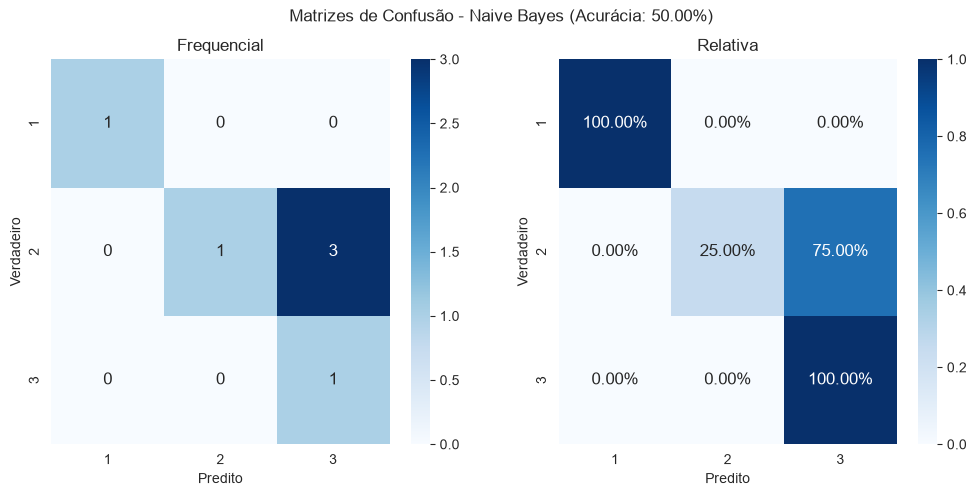

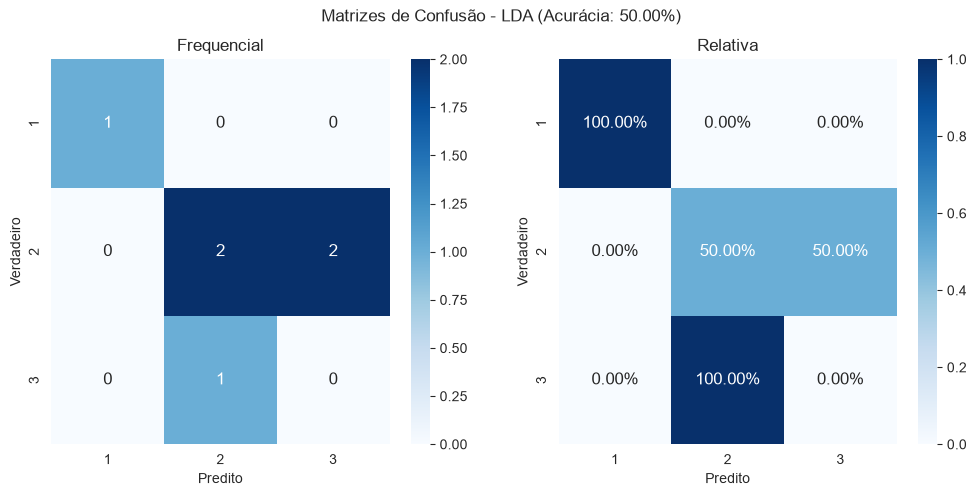

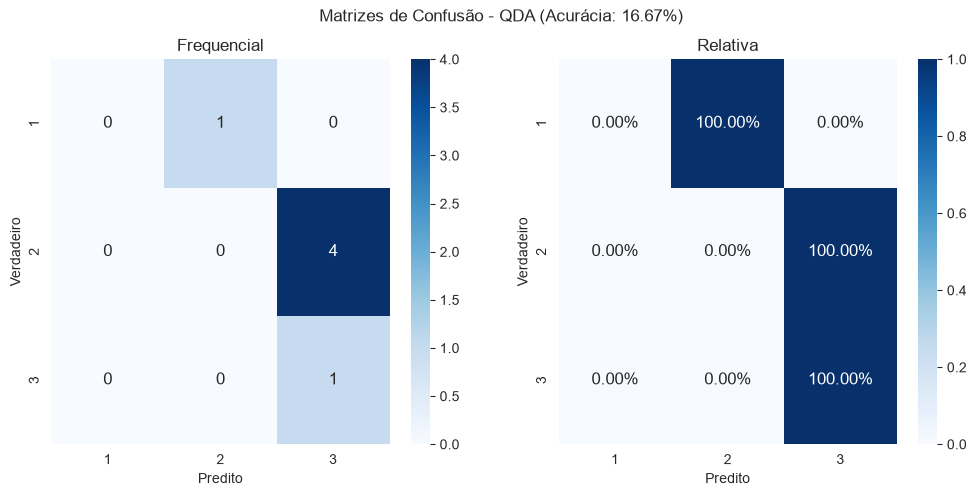

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
lda_acuracia = accuracy_score(y_test, lda_predicoes)
qda_acuracia = accuracy_score(y_test, qda_predicoes)

def plota_matriz_confusao(y_true, y_pred, classes, titulo="Matrizes de Confusão"):
    cm_abs = confusion_matrix(y_true, y_pred, labels=classes)
    cm_rel = confusion_matrix(y_true, y_pred, labels=classes, normalize='true')
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    hmap_args = {
        "annot": True,
        "cmap": "Blues",
        "xticklabels": classes,
        "yticklabels": classes,
        "annot_kws": {"size": 12}
    }
    sns.heatmap(cm_abs, fmt='d', ax=ax[0], **hmap_args)
    sns.heatmap(cm_rel, fmt='.2%', ax=ax[1], **hmap_args)
    _ = ax[0].set_xlabel('Predito')
    _ = ax[0].set_ylabel('Verdadeiro')
    _ = ax[0].set_title('Frequencial')
    _ = ax[1].set_xlabel('Predito')
    _ = ax[1].set_ylabel('Verdadeiro')
    _ = ax[1].set_title('Relativa')
    fig.suptitle(titulo)

for modelo, acc, preds in [
    ("Naive Bayes", naive_bayes_acuracia, naive_bayes_predicoes), 
    ("LDA", lda_acuracia, lda_predicoes), 
    ("QDA", qda_acuracia, qda_predicoes)
]:
    plota_matriz_confusao(
        y_test, 
        preds, 
        classes=[1, 2, 3], 
        titulo=f"Matrizes de Confusão - {modelo} (Acurácia: {acc:.2%})"
    )

Os resultados são horríveis como esperado de um dataset com tão poucas amostras e sem separação clara entre as classes.

### Comparação de performance média

No item anterior, a semente aletória do embaralhamento de amostras foi fixado. 
Aqui, ele assume 10 valores distintos, para os quais o processo de treino, teste e avaliação é repetido. 
Ao final, são apresentados os valores médios das métricas (acurácia, matriz de confusão, F1).

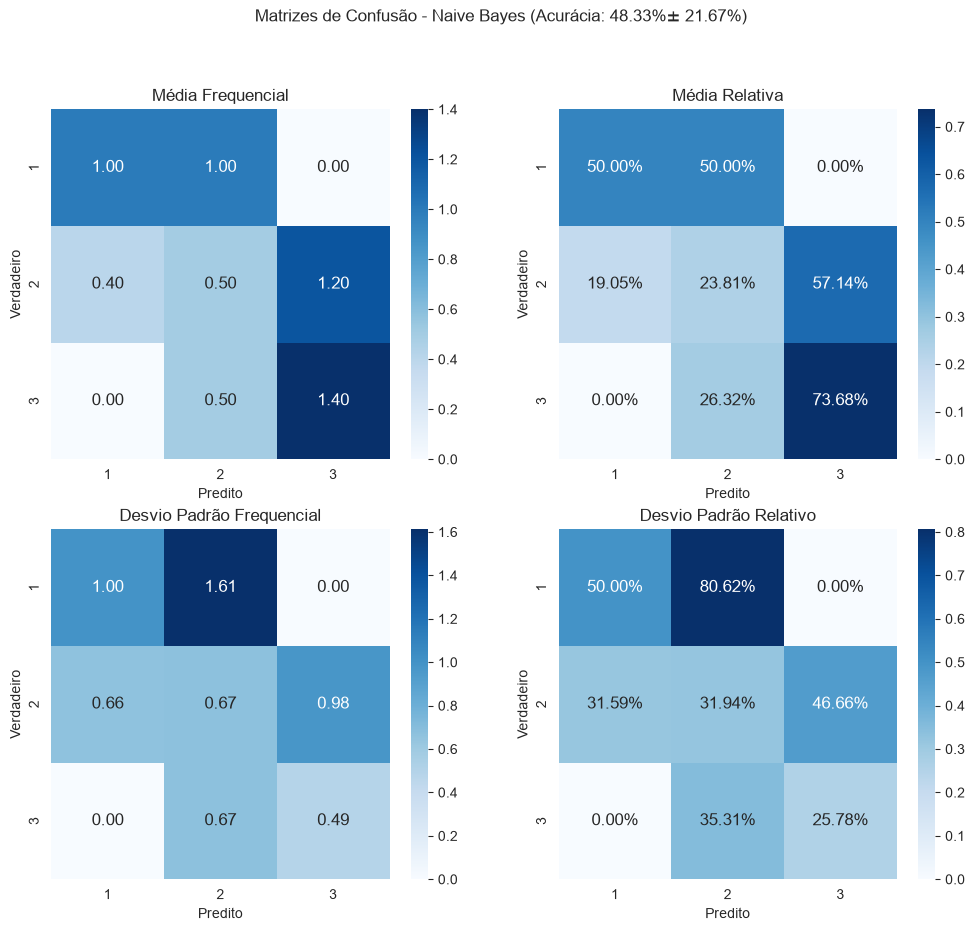

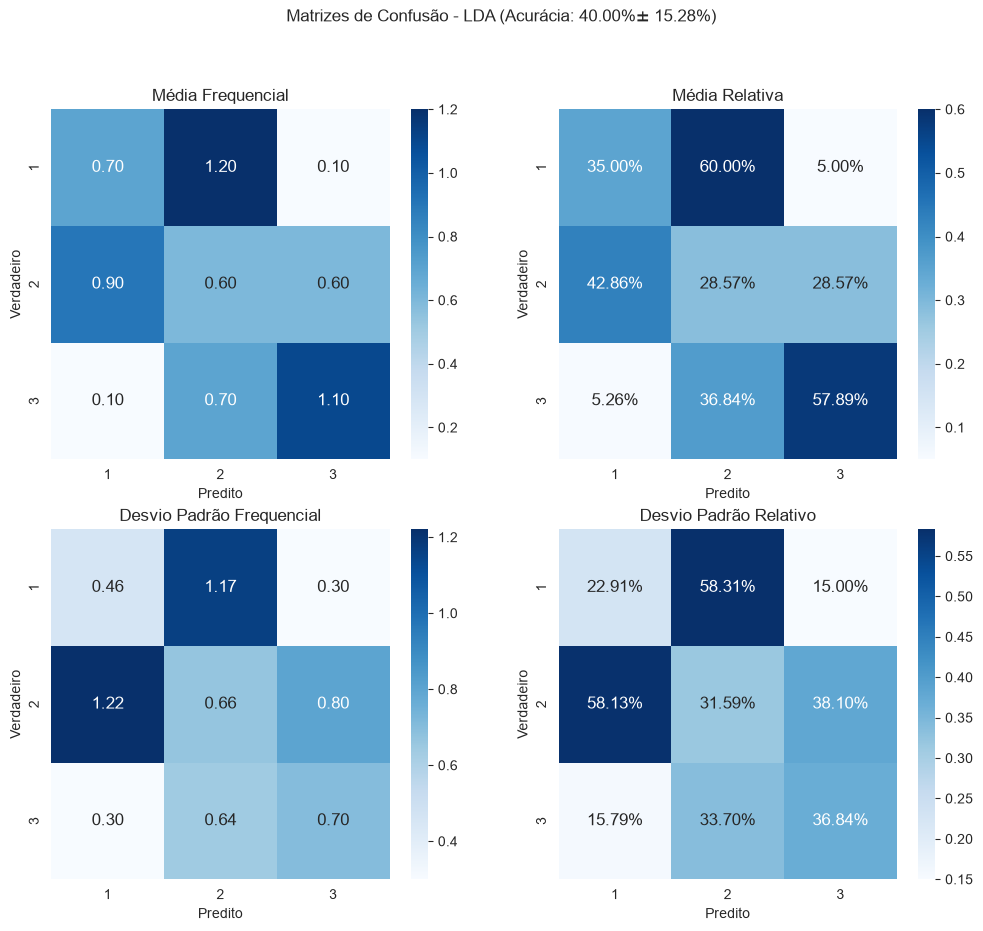

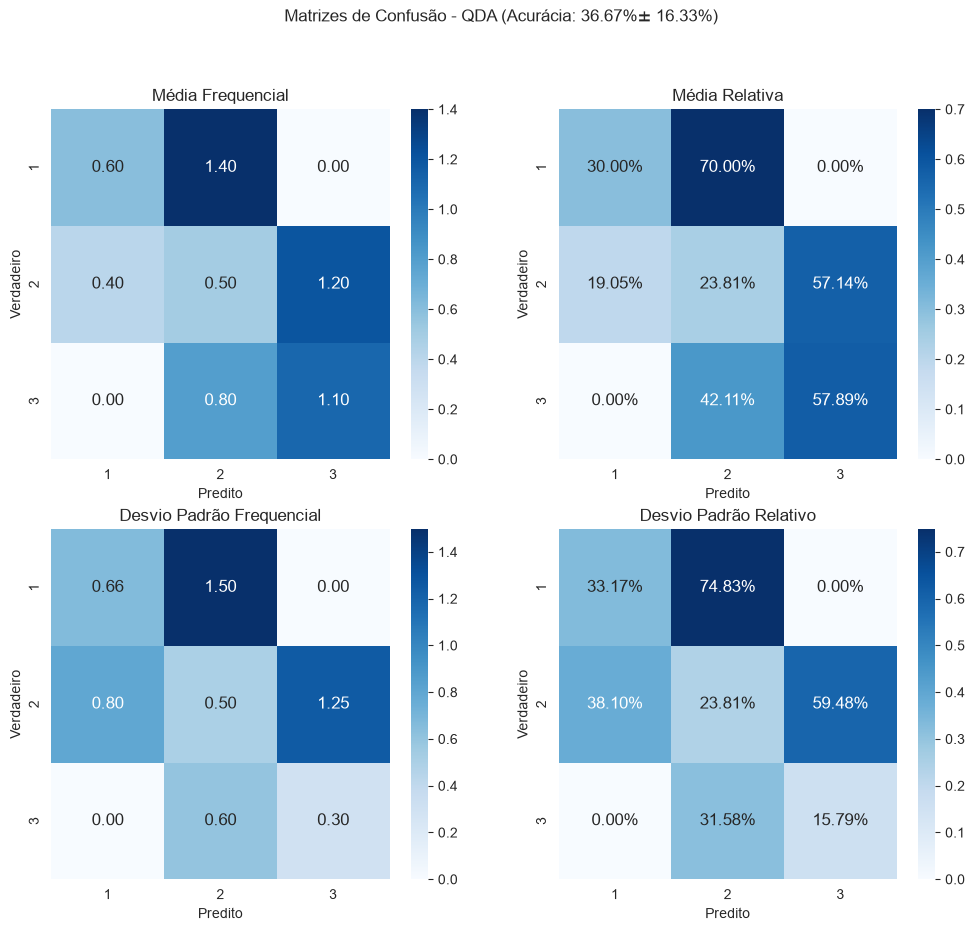

In [9]:
sementes_aleatorias = [42, 8, 21, 85, 100, 123, 456, 789, 101_112, 131_415]

naive_bayes_estocastico = GaussianNB()
lda_estocastico = LinearDiscriminantAnalysis()
qda_estocastico = QuadraticDiscriminantAnalysis(solver="eigen", shrinkage=1e-3)

naive_bayes_resultados = {"acurácias": [], "matrizes": []}
lda_resultados = {"acurácias": [], "matrizes": []}
qda_resultados = {"acurácias": [], "matrizes": []}

for s in sementes_aleatorias:
    # Split
    x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=s, shuffle=True)
    
    # Treino
    naive_bayes_estocastico.fit(x_train, y_train)
    lda_estocastico.fit(x_train, y_train)
    qda_estocastico.fit(x_train, y_train)

    # Teste
    naive_bayes_predicoes = naive_bayes_estocastico.predict(x_test)
    lda_predicoes = lda_estocastico.predict(x_test)
    qda_predicoes = qda_estocastico.predict(x_test)

    # Avaliação - acuracia
    naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
    lda_acuracia = accuracy_score(y_test, lda_predicoes)
    qda_acuracia = accuracy_score(y_test, qda_predicoes)

    # Armazenamento dos resultados - Naive Bayes
    naive_bayes_resultados["acurácias"].append(naive_bayes_acuracia)
    naive_bayes_resultados["matrizes"].append(confusion_matrix(y_test, naive_bayes_predicoes))

    # Armazenamento dos resultados - LDA
    lda_resultados["acurácias"].append(lda_acuracia)
    lda_resultados["matrizes"].append(confusion_matrix(y_test, lda_predicoes))

    # Armazenamento dos resultados - QDA
    qda_resultados["acurácias"].append(qda_acuracia)
    qda_resultados["matrizes"].append(confusion_matrix(y_test, qda_predicoes))

# Resultados
for modelo, resultados in [
    ("Naive Bayes", naive_bayes_resultados), 
    ("LDA", lda_resultados), 
    ("QDA", qda_resultados)
]:
    cm_media = np.mean(resultados["matrizes"], axis=0)
    cm_desvio_padrao = np.std(resultados["matrizes"], axis=0)

    cm_media_relativa = cm_media / cm_media.sum(axis=1)[:, np.newaxis]
    cm_desvio_padrao_relativa = cm_desvio_padrao / cm_media.sum(axis=1)[:, np.newaxis]

    acc_media = np.mean(resultados["acurácias"])
    acc_desvio_padrao = np.std(resultados["acurácias"])

    titulo = f"Matrizes de Confusão - {modelo} (Acurácia: {acc_media:.2%}$\\pm$ {acc_desvio_padrao:.2%})"
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    hmap_args = {
        "annot": True,
        "cmap": "Blues",
        "xticklabels": [1, 2, 3],
        "yticklabels": [1, 2, 3],
        "annot_kws": {"size": 12}
    }
    sns.heatmap(cm_media, ax=axs[0, 0], fmt=".2f",**hmap_args)
    sns.heatmap(cm_media_relativa, ax=axs[0, 1], fmt=".2%", **hmap_args)
    sns.heatmap(cm_desvio_padrao, ax=axs[1, 0], fmt=".2f",**hmap_args)
    sns.heatmap(cm_desvio_padrao_relativa, ax=axs[1, 1], fmt=".2%", **hmap_args)

    axs[0, 0].set_title("Média Frequencial")
    axs[0, 1].set_title("Média Relativa")
    axs[1, 0].set_title("Desvio Padrão Frequencial")
    axs[1, 1].set_title("Desvio Padrão Relativo")

    for ax in axs.flat:
        ax.set_xlabel('Predito')
        ax.set_ylabel('Verdadeiro')
    fig.suptitle(titulo)
    

Tabela das métricas:

In [10]:
df_metricas = pd.DataFrame({
    "Modelo": ["Naive Bayes", "LDA", "QDA"],
    "Acurácia Média": [
        np.mean(naive_bayes_resultados["acurácias"]),
        np.mean(lda_resultados["acurácias"]),
        np.mean(qda_resultados["acurácias"])
    ],
    "Acurácia Desvio Padrão": [
        np.std(naive_bayes_resultados["acurácias"]),
        np.std(lda_resultados["acurácias"]),
        np.std(qda_resultados["acurácias"])
    ]
})

display(df_metricas.style.format({
    "Acurácia Média": "{:.2%}",
    "Acurácia Desvio Padrão": "{:.2%}",
}))

,Modelo,Acurácia Média,Acurácia Desvio Padrão
0,Naive Bayes,48.33%,21.67%
1,LDA,40.00%,15.28%
2,QDA,36.67%,16.33%


### Melhor classificador

Nenhum classificador apresentou acurácia superior a 50% em média, 
e em particular o QDA é quase tão ruim quanto um classificador elatório.

Com isso dito, Naïves Bayes teve a maior acurácia média.

### Intervalos de confiança 

Como o desvio-padrão real das acurácias enquanto variáveis randômicas é desconhecido, a distribuição t de Student é a mais adequada para auxiliar na dedução dos intervalos de confiança.

Para um processo randômico i.i.d. com $N$ amostras, média amostral $\overline{X}$ e desvio-padrão amostral $s$, tem-se

$$
    \overline{X} - t_{\alpha, \nu} \frac{S}{\sqrt{N}} \leq \mu \leq \overline{X} + t_{\alpha, \nu} \frac{S}{\sqrt{N}}
$$

onde $\alpha$ é o nível de confiança desejado, $\nu=N-1$ a quantidade de graus de liberdade, e $\mu$ a média subjacente de $X$.

Os coeficientes $t_{\alpha, \nu}$ são aproximados numericamente e tabelados para vários $\alpha$ e $\nu$.
Para o caso desta questão, [tem-se](https://en.wikipedia.org/wiki/Student%27s_t-distribution#Table_of_selected_values)

$$
    t_{95\%, 9} = 2.262, \quad
    t_{99.8\%, 9} = 4.297
$$

O código abaixo calcula os intervalos a partir dos resultados do item 7.2 com base na equação e valores acima.

In [11]:
t_95 = 2.262
t_99 = 4.297

for c, t in [(95, t_95), (99.8, t_99)]:
    intervalos = {}
    
    amplitude_naive_bayes = t * np.std(naive_bayes_resultados["acurácias"]) / np.sqrt(len(naive_bayes_resultados["acurácias"]))
    min_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) - amplitude_naive_bayes
    max_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) + amplitude_naive_bayes
    intervalo_naive_bayes = (min_naive_bayes, max_naive_bayes, 2*amplitude_naive_bayes)
    
    amplitude_lda = t * np.std(lda_resultados["acurácias"]) / np.sqrt(len(lda_resultados["acurácias"]))
    min_lda = np.mean(lda_resultados["acurácias"]) - amplitude_lda
    max_lda = np.mean(lda_resultados["acurácias"]) + amplitude_lda
    intervalo_lda = (min_lda, max_lda, 2*amplitude_lda)

    amplitude_qda = t * np.std(qda_resultados["acurácias"]) / np.sqrt(len(qda_resultados["acurácias"]))
    min_qda = np.mean(qda_resultados["acurácias"]) - amplitude_qda
    max_qda = np.mean(qda_resultados["acurácias"]) + amplitude_qda
    intervalo_qda = (min_qda, max_qda, 2*amplitude_qda)

    intervalos["Naive Bayes"] = intervalo_naive_bayes
    intervalos["LDA"] = intervalo_lda
    intervalos["QDA"] = intervalo_qda

    display(pd.DataFrame(
        intervalos, 
        index=["Limite Inferior", "Limite Superior", "Delta"]).style.format("{:.2%}").set_caption(
            f"Intervalos de Confiança de {c}% para Acurácia"
        )
    )

,Naive Bayes,LDA,QDA
Limite Inferior,32.84%,29.07%,24.99%
Limite Superior,63.83%,50.93%,48.35%
Delta,31.00%,21.85%,23.36%


,Naive Bayes,LDA,QDA
Limite Inferior,18.89%,19.24%,14.48%
Limite Superior,77.77%,60.76%,58.86%
Delta,58.88%,41.51%,44.38%


Como esperado da pequena quantidade de amostras, os intervalos de confiança são muito largos, e não permitem afirmar muita coisa.